# Instacart Data Analysis

This project explores customer purchasing behavior using transactional grocery data. The goal is to understand how customers interact with products over time, identify reorder patterns, and extract insights that could inform product strategy, inventory planning, and user experience decisions.

The analysis moves from raw, imperfect data toward structured insight. Each step reflects practical data work: identifying inconsistencies, cleaning and validating datasets, combining multiple sources, and transforming data into meaningful summaries. The focus throughout is not only on producing results, but on ensuring those results are reliable and interpretable.

The workflow demonstrates the ability to work with relational datasets, apply efficient transformations using Pandas, and translate quantitative outputs into actionable observations relevant to business contexts.


The results of this step reveal the following:

## 
# Instacart Market Basket

## Importing the required libraries

In [1]:
# Import the libraries you'll need for this analysis
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the datasets
# Note: These files use semicolon (;) as the separator instead of comma
orders         = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products       = pd.read_csv('/datasets/products.csv', sep=';')
departments    = pd.read_csv('/datasets/departments.csv', sep=';')
aisles         = pd.read_csv('/datasets/aisles.csv', sep=';')
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')

## Analyze the data

In the cells below, I display the datasets using `.info()` and `.head()` to gain insights into their structure and content.

- `.info()`: Provides a concise summary of the dataset, including the data types, non-null counts, and memory usage.
- `.head()`: Displays the first few rows of the dataset, offering a quick overview of the data values.

In [3]:
# In this cell, type "orders" below this line and execute the cell
print(orders.head())

   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   
3   1768857    82516            56          0                 20   
4   3007858   196724             2          4                 12   

   days_since_prior_order  
0                    30.0  
1                     9.0  
2                     2.0  
3                    10.0  
4                    17.0  


In [4]:
# In this cell, type "products" below this line and execute the cell
print(products.head())

   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  


The results of this step reveal the following:

## 
Repeat this process for each dataset to understand the structure, including the types of columns and rows they contain. Add additional code cells as needed for the .

In [5]:
# In this cell, type "orders.info() below this line and execute the cell
print(orders.info(show_counts=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
None


The "Non-Null Count" column provides information about any missing values in each column of the dataset. With a total of 478,952 entries, observe any columns where the non-null count is less than this number to identify missing values.

In [6]:
# In this cell, run orders_products.info() below, but include the argument show_counts=True since this is a large file.
print(order_products.info(show_counts=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None


Repeat the use of .info() on the remaining datasets to identify missing values and understand their structure. Check the "Non-Null Count" for each dataset to spot any columns with missing values.

In [7]:

products       = pd.read_csv('/datasets/products.csv', sep=';')
departments    = pd.read_csv('/datasets/departments.csv', sep=';')
aisles         = pd.read_csv('/datasets/aisles.csv', sep=';')

#Following the instructions above, I'm using .info() on the remaining datasets to identify missing volaues and understand their structures.
print('------------------------------------------------------------------------------------') #Dividing line to separate results for a cleaner look
print('Products Info') #Title to clearly identify which DataFrame we're looking at the info for
print(products.info(show_counts=True))
print('------------------------------------------------------------------------------------') #Dividing line to separate results for a cleaner look
print('Departments Info') #Title to clearly identify which DataFrame we're looking at the info for
print(departments.info(show_counts=True))
print('------------------------------------------------------------------------------------') #Dividing line to separate results for a cleaner look
print('Aisles Info') #Title to clearly identify which DataFrame we're looking at the info for
print(aisles.info(show_counts=True))
print('------------------------------------------------------------------------------------') #Dividing line to separate results for a cleaner look

------------------------------------------------------------------------------------
Products Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None
------------------------------------------------------------------------------------
Departments Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes
None
--------------------------------------------

## Find and Remove Missing Values

I noticed that some columns contain missing values.

Here are some useful code snippets:

```python
# Identify missing values in each column
print(dataset.isnull().sum())

# Display rows where a specific column has missing values
print(dataset[dataset['column_name'].isna()])

# Confirm no missing values remain
print(dataset.isnull().sum())
```

### `products` Data Frame

I will begin by addressing the missing values in the `products` data frame.

In [8]:
# Display rows where the product_name column has missing values
print(products[products['product_name'].isna()])

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


It seems suspicious that all rows with missing `product_name` might be associated with `aisle_id` 100 and `department_id` 21. Let’s verify this by checking if any rows with missing `product_name` have an `aisle_id` different from 100 and 21. This will help us confirm if the issue is isolated to this aisle or spread across others.

In [9]:
# Combine conditions to check for missing product names in aisles other than 100
oa_filter = (products['product_name'].isna()) & (products['aisle_id'] != 100)
other_aisles = products[oa_filter]
print(other_aisles)

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


In [10]:
# Combine conditions to check for missing product names in departments other than 21
d_filter = (products['product_name'].isna()) & (products['department_id'] != 21)
other_departments = products[d_filter]
print(other_departments)

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


To better understand the missing product_name values, let’s determine what department_id 21 and aisle_id 100 represent by referencing the departments and aisles tables.

In [11]:
# What is this aisle and department?
print(departments[departments['department_id'] == 21])
print(aisles[aisles['aisle_id'] == 100])

    department_id department
20             21    missing
    aisle_id    aisle
99       100  missing


In [12]:
# Fill missing product names with 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknown')

### `orders` data frame

Now The analysis will fill in missing values from the `orders` table.

In [13]:
# Display rows where the days_since_prior_order column has missing values
print(orders[orders['days_since_prior_order'].isna()])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

In [14]:
# Are there any missing values where it's not a customer's first order?
print(orders[(orders['days_since_prior_order'].isna()) & (orders['order_number'] != 1)])

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


All of the missing `'days_since_prior_order'` values correspond to a customer's first ever order. This makes sense because there is no prior order! I'll leave the values as `NaN` so the column can remain numeric. Also, the `NaN` values shouldn't interfere with any calculations I might do using this column.

### `order_products` data frame

Now The analysis will fill in missing values from the order_products table.

In [15]:
# Display rows where the add_to_cart_order column has missing values
print(order_products[order_products['add_to_cart_order'].isna()])

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]


In [16]:
# Use .min() and .max() to find the minimum and maximum values for this column.
print(f"The minimum value for the add_to_cart_order column is {int(order_products['add_to_cart_order'].min())}.")
print()
print(f"The maximum value for this column is {int(order_products['add_to_cart_order'].max())}.")

The minimum value for the add_to_cart_order column is 1.

The maximum value for this column is 64.


In [17]:
# Save all order IDs with at least one missing value in 'add_to_cart_order'
import numpy as np #Importing Numerical Python to use tools within.
orders_with_missing = np.unique(order_products[order_products['add_to_cart_order'].isna()]['order_id']) #Saving Order ID's with missing Add-To-Cart data to new variable.
print(f"There are {len(orders_with_missing)} order IDs with at least one missing value in the 'add_to_cart_order' column.") #Counts the number of orders with at least one missing value in 'add_to_cart_order'

There are 70 order IDs with at least one missing value in the 'add_to_cart_order' column.


In [18]:
# Do all orders with missing values have more than 64 products?
filter_64 = ((order_products['order_id'].isin(orders_with_missing)) & (order_products['add_to_cart_order'] == 64))
orders_with_64th_item = order_products[filter_64]
print(orders_with_64th_item) #All 70 order IDs have at least 64 products added to the cart, meaning an error happend with the 'add_to_cart_order' values after 64. 

         order_id  product_id  add_to_cart_order  reordered
76044     1386261       31847               64.0          0
154176     854647       22922               64.0          0
177733    3383594        7970               64.0          0
213282    2470674       30257               64.0          0
233518    1968313         495               64.0          1
...           ...         ...                ...        ...
4148751   2999801       24722               64.0          1
4235552   3308010        3888               64.0          1
4409436    747668       31268               64.0          0
4419785   1633337          34               64.0          0
4432234      9310       21332               64.0          0

[70 rows x 4 columns]


In [19]:
# Replace missing values with 999 and convert column to integer type
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999)

The results of this step reveal the following:

## 
For some reason, any item placed in the cart 65th or later has a missing value in the `'add_to_cart_order'` column. Maybe the data type of that column in the database could only hold integer values from 1 to 64. I've decided to replace the missing values with a code value, 999, that represents an unknown placed in cart order above 64. I also converted the column to integer data type. I just need to be careful to remember this if I perform calculations using this column during our .

Other sensible code values I could've used are 0 or -1 because they don't show up elsewhere in the dataset and they don't have any real physical meaning for this variable.

Also note that, for orders with exactly 65 items, I could replace the missing value with 65. But I're going to neglect that for now since I can't determine the 65th item for all orders with 66 items or more.

The results of this step reveal the following:

## 
## Find and Remove Duplicate Values from All the Datasets

Each dataset may contain duplicate rows, which can lead to redundancy and affect the accuracy of our . To handle this:

1. Use the `.duplicated()` method to identify duplicate rows. This method returns a Boolean series where `True` indicates a duplicate row.
2. Apply the `.drop_duplicates()` method to remove these duplicate rows, ensuring a cleaner dataset.
3. Optionally, This allows set the `keep` parameter in `.drop_duplicates()` to specify which duplicate to retain (`'first'` or `'last'`).

Here is some example code for reference:
```python
# Check for duplicates
print(dataset.duplicated().sum())  # Number of duplicate rows

# View duplicate rows
print(dataset[dataset.duplicated()]

# Remove duplicates
dataset = dataset.drop_duplicates().reset_index(drop=True)

# Confirm removal
print(dataset.duplicated().sum())  # Should return 0
```

Repeat this process for all datasets to ensure they are free of duplicate rows.

### `orders` data frame

In [20]:
# Find the number of duplicate rows in the orders dataframe
print(orders.duplicated().sum())

15


In [21]:
# View the duplicate rows
print(orders[orders.duplicated()])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48          3 

In [22]:
# Remove duplicate orders
orders = orders.drop_duplicates().reset_index(drop=True)

In [23]:
# Double check for duplicate rows
print(orders.duplicated().sum())

0


### `products` data frame

In [24]:
# Check for fully duplicate rows
print(products[products.duplicated()])

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


In [25]:
# Check for just duplicate product IDs using subset='product_id' in duplicated()
print(products[products['product_id'].duplicated()])

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


Hint: To identify duplicate product names more effectively, convert the names to lowercase for consistent comparison. Use the .str.lower() method on the product_name column to standardize the text before checking for duplicates.

In [26]:
# Check for just duplicate product names (convert names to lowercase to compare better)
products['product_name'] = products['product_name'].str.lower()
print(products[products['product_name'].duplicated()])

       product_id                                     product_name  aisle_id  \
71             72                                          unknown       100   
109           110                                          unknown       100   
296           297                                          unknown       100   
416           417                                          unknown       100   
436           437                                          unknown       100   
...           ...                                              ...       ...   
49689       49690                    high performance energy drink        64   
49690       49691                    original pancake & waffle mix       130   
49691       49692  organic instant oatmeal light maple brown sugar       130   
49692       49693                           spring water body wash       127   
49693       49694                          burrito- steak & cheese        38   

       department_id  
71              

I will see what that looks like in our dataset :

In [27]:
products[products['product_name'].str.lower() == 'high performance energy drink']

,product_id,product_name,aisle_id,department_id
22540,22541,high performance energy drink,64,7
49689,49690,high performance energy drink,64,7


In [28]:
# Drop duplicate product names (case insensitive)
products['product_name'].drop_duplicates().reset_index(drop = True)

0                               chocolate sandwich cookies
1                                         all-seasons salt
2                     robust golden unsweetened oolong tea
3        smart ones classic favorites mini rigatoni wit...
4                                green chile anytime sauce
                               ...                        
48328            vodka- triple distilled- twist of vanilla
48329                   en croute roast hazelnut cranberry
48330                                     artisan baguette
48331           smartblend healthy metabolism dry cat food
48332                               fresh foaming cleanser
Name: product_name, Length: 48333, dtype: object

### `departments` data frame

In [29]:
# Check for duplicate entries in the departments dataframe
print(departments[departments.duplicated()])

Empty DataFrame
Columns: [department_id, department]
Index: []


### `aisles` data frame

In [30]:
# Check for duplicate entries in the aisles dataframe
print(aisles[aisles.duplicated()])

Empty DataFrame
Columns: [aisle_id, aisle]
Index: []


### `order_products` data frame

In [31]:
# Check for duplicate entries in the order_products dataframe
print(order_products[order_products.duplicated()])

Empty DataFrame
Columns: [order_id, product_id, add_to_cart_order, reordered]
Index: []


The results of this step reveal the following:

## 
I have now successfully cleaned our data. I will begin our exploratory data .

### [A1] Verify that the `'order_hour_of_day'` and `'order_dow'` values in the `orders` tables are sensible (i.e. `'order_hour_of_day'` ranges from 0 to 23 and `'order_dow'` ranges from 0 to 6)

To verify that the values in the `order_hour_of_day` and `order_dow` columns are sensible:

1. **Check unique values**: Use `.unique()` on each column to extract all distinct values present.
2. **Sort the results**: Use `sorted()` to arrange the unique values in ascending order for easier verification.
3. **Validate ranges**:
   - Ensure `order_hour_of_day` values range from 0 to 23 (representing hours of the day).
   - Ensure `order_dow` values range from 0 to 6 (representing days of the week).

This process confirms that the data aligns with expected ranges and there are no out-of-bound or invalid entries.

In [32]:
print('Orders hour of the day include:')
print(orders['order_hour_of_day'].unique())
print()
print('Orders day of the week include:')
print(orders['order_dow'].unique())

Orders hour of the day include:
[13 12 19 20 11  8 18 15 16  9 22 10  0 14 17  1  7  6  2 21  3 23  5  4]

Orders day of the week include:
[6 5 0 4 3 1 2]


In [33]:
print('Orders hour of the day (sorted):')
print(sorted(orders['order_hour_of_day'].unique()))
print()
print('Orders day of the week (sorted):')
print(sorted(orders['order_dow'].unique()))

Orders hour of the day (sorted):
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

Orders day of the week (sorted):
[0, 1, 2, 3, 4, 5, 6]


### [A2] What time of day do people shop for groceries?

To determine the time of day people shop for groceries, analyze the order_hour_of_day column in the orders dataset. Use .value_counts() to count the number of orders placed at each hour, and then sort the results by the hour for a clear chronological order.

Finally, visualize the data with a bar plot to easily observe the shopping trends across different times of the day.

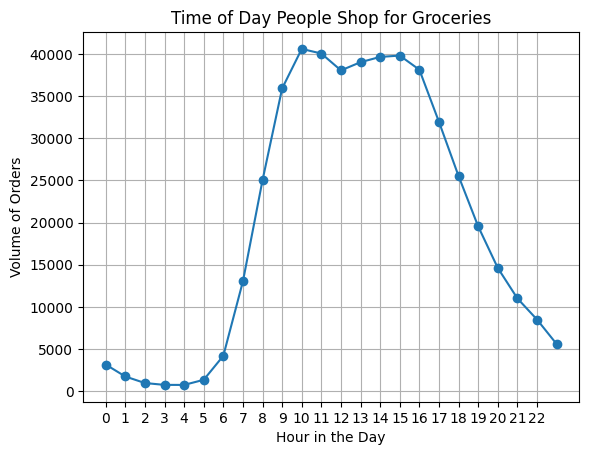

In [34]:
from matplotlib import pyplot as plt

hourly_orders = orders['order_hour_of_day'].value_counts().sort_index()

hourly_orders.plot(title = 'Time of Day People Shop for Groceries',
                  xlabel = 'Hour in the Day',
                  ylabel = 'Volume of Orders',
                  style = 'o-',
                  grid = True,
                   xticks = range(0, 23, 1)
                  )

plt.show()

The results of this step reveal the following:

## 
#### :
- The busiest time of day is between 8 AM and 6 PM.
- Orders peak at 10 AM, making it a critical time of day for ensuring Instacart delivery drivers and Instacart servers are ready for the order volume.

Most orders occur between 9:00 AM and 5:00 PM, with peaks at 10:00 AM and 3:00 PM

### [A3] What day of the week do people shop for groceries?

To figure out what day of the week people shop for groceries, analyze the order_dow column in the orders dataset. Use .value_counts() to count the number of orders for each day of the week, and then sort the results by the day index to maintain the correct order.

I visualize the data with a bar plot to clearly observe shopping patterns across the days of the week.

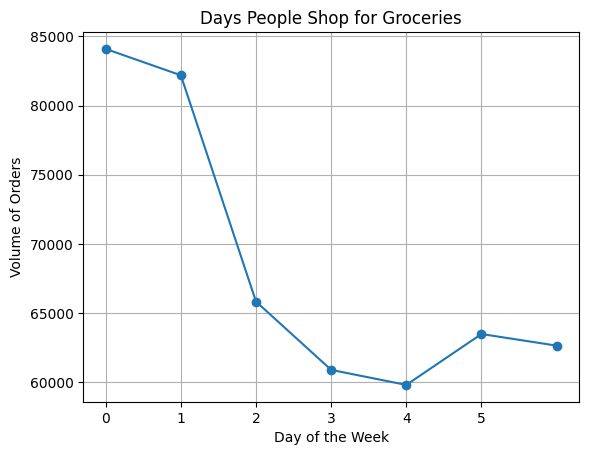

In [35]:
orders_per_day = orders['order_dow'].value_counts().sort_index()

orders_per_day.plot(title = 'Days People Shop for Groceries',
                   ylabel = 'Volume of Orders',
                   xlabel = 'Day of the Week',
                   style = 'o-',
                    grid = True,
                    xticks = range(0, 6, 1)
                   )

plt.show()

The results of this step reveal the following:

## 
#### :
- Assuming Sunday = 0, customers place most of their orders on Sunday and Monday.
- Orders sharply drop off on Tuesday, Wednesday, and Thursday.
- On Friday, orders rise a bit and then drop slightly on Saturday. This seems to indicate people are either finishing up the work week or getting some supplies for their weekend plans.

The data dictionary does not state which integer corresponds to which day of the week. Assuming Sunday = 0, then people place more orders at the beginning of the week (Sunday and Monday).

### [A4] How long do people wait until placing another order?

To understand how long people wait before placing another order, analyze the days_since_prior_order column in the orders dataset. Use .value_counts() to count how many orders were placed for each interval of days, then sort the results by the number of days for clarity.

I visualize the data using a bar plot to observe patterns in ordering frequency over time.

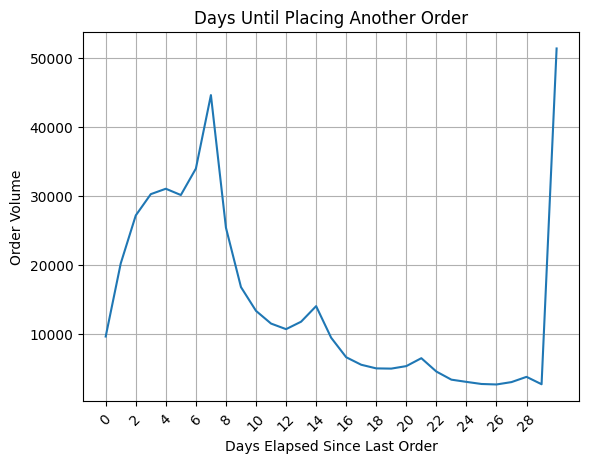

In [36]:
days_until_reordering = orders['days_since_prior_order'].value_counts().sort_index()

days_until_reordering.plot(title = 'Days Until Placing Another Order',
                          ylabel = 'Order Volume',
                          xlabel = 'Days Elapsed Since Last Order',
                          grid = True,
                          xticks = range(0, 30, 2),
                          rot = 45)

plt.show()

The results of this step reveal the following:

## 
#### :
- Most orders are made 7 days after the last order.
- This is a great data point for understanding the most common frequency customers like to reorder at.
- There are other spikes in orders at the 2-week, 3-week, and 4-week mark.
- This is likely due to having automatically reoccuring subscriptions set to place an order ever 1, 2, 3, or 4 weeks.

The 0 values probably correspond to customers who placed more than one order on the same day.

The max value of 30 days and the high spike at that value is puzzling though. The spike might be explained by people who set up recurring subscriptions to automatically order once a month. But that doesn't explain why there are no values above 30 days. I would expect many customers to place orders less often than once a month. Maybe those customers were intentionally excluded from the dataset.

Disregarding the spike at 30 days, most people wait between 2 to 10 days in between orders. The most common wait time is 7 days. In other words, it's common for people to place weekly grocery orders. Interestingly, in the tail of the distribution I also see small spikes at 14, 21, and 28 days. These would correspond to orders every 2, 3, or 4 weeks.

### [B1] Is there a difference in `'order_hour_of_day'` distributions on Wednesdays and Saturdays? Plot the bar charts for both days and describe the differences that see.

To determine if there's a difference in the `order_hour_of_day` distributions on Wednesdays and Saturdays, follow these steps:

1. **Create masks** for Wednesday (`order_dow == 3`) and Saturday (`order_dow == 6`) to filter the orders data.
2. **Count the order hours** for each day using `.value_counts()` and sort them by hour with `.sort_index()` for clarity.
3. **Combine the counts** for both days into a single DataFrame using `pd.concat()`, and label the columns for easier interpretation.

After preparing the data, plot bar charts for both days to visually compare the distribution of order times. Look for patterns such as peaks or differences in the busiest times throughout the day.

In [37]:
wednesday_orders = orders[orders['order_dow'] == 3]['order_hour_of_day'].value_counts().sort_index()
saturday_orders = orders[orders['order_dow'] == 6]['order_hour_of_day'].value_counts().sort_index()

In [38]:
wednesday_and_saturday = pd.concat([wednesday_orders, saturday_orders], axis = 'columns')

In [39]:
wednesday_and_saturday.columns = ['wednesday_orders', 'saturday_orders']

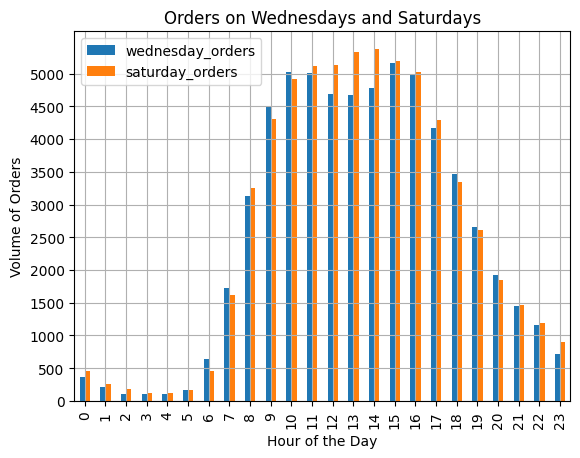

In [40]:
wednesday_and_saturday.plot(title = 'Orders on Wednesdays and Saturdays',
                           xlabel = 'Hour of the Day',
                           ylabel = 'Volume of Orders',
                           grid = True,
                           xticks = range(0, 24, 1),
                            yticks = range(0, 5500, 500),
                           kind = 'bar')
plt.show()

The results of this step reveal the following:

## 
#### :
- Wednesday does experience a dip in orders midday, relative to Saturday. This is likely due to work obligations or because they're currently focused on getting lunch.
- The most popular time, by far, is between 9 am and 5 pm.
- It's interesting how orders between 12 am and 5 am are negligable, while orders stay relatively high up until 11pm. It looks like a decent segment of customers might be having some late-night cravings or doing some last-minute shopping.

There's a small dip from 11h to 13h on Wednesdays. This dip is absent on Saturdays. Maybe this dip can be attributed to people who don't use Instacart because they have lunch somewhere between 11h and 13h.

### [B2] What's the distribution for the number of orders per customer?

To explore the distribution of the number of orders per customer:

1. **Group the data** by `user_id` to calculate the total number of orders for each customer. Use `.groupby('user_id')` and count the `order_id` for each group.
2. **Sort the results** using `.sort_values()` for better readability.
3. **Visualize the distribution** using a histogram to observe how many orders most customers typically place.

Adjust the number of bins in the histogram to refine the visualization and better capture the pattern.

In [41]:
orders_per_customer = orders.groupby('user_id')['order_id'].count().sort_values()

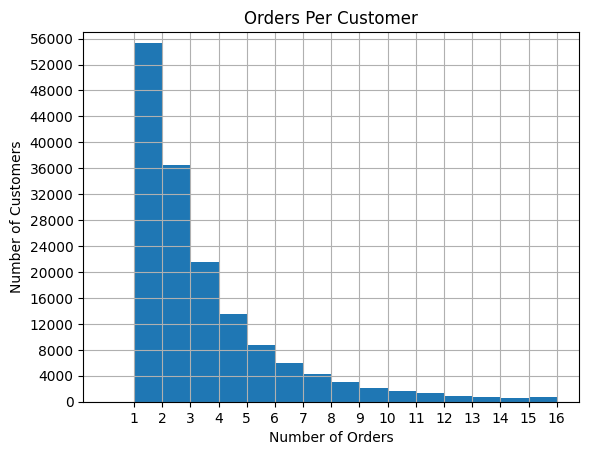

In [42]:
orders_per_customer.plot(kind = 'hist',
                        bins = 16,
                        xticks = range(1, 17, 1),
                        range = (0, 16),
                        yticks = range(0, 57000, 4000),
                        title = 'Orders Per Customer',
                        grid = True,
                        ylim = (0, 57000))

plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')

plt.show()

The results of this step reveal the following:

## 
#### :
- The large majority of customers in the dataset have only placed between 1 and 6 orders.
- This data could be used to target promotions at customers most likely to reorder. Typically, those are the customers who have already reordered. Efforts could be focused from most loyal to least loyal customer, making promotions more efficient.

Most customers in the dataset have placed between 1 and 10 orders, with number of orders per customer sharply decreasing after just 1 order.

### [B3] What are the top 20 popular products (display their id and name)?

To identify the top 20 most popular products:

1. **Merge the datasets**: Combine `order_products` and `products` on `product_id` to access both the product IDs and names in a single DataFrame.
2. **Group the data**: Group by both `product_id` and `product_name` to aggregate the order counts for each product using `.size()`.
3. **Sort the results**: Use `.sort_values(ascending=False)` to rank products by their popularity.
4. **Display the top 20**: Use `.head(20)` to focus on the most frequently ordered products.
5. **Visualize the results**: Create a bar chart to highlight the top products and their order counts.

This will give a clear view of the most popular products and their ranking.


In [43]:
orders_and_products = order_products.merge(products,
                                          left_on = 'product_id',
                                          right_on = 'product_id')

In [44]:
grouped_products = orders_and_products.groupby(['product_id', 'product_name']).size()
grouped_products = grouped_products.sort_values(ascending=False)
top_20 = grouped_products.head(20)
print(top_20)

product_id  product_name            
24852       banana                      66050
13176       bag of organic bananas      53297
21137       organic strawberries        37039
21903       organic baby spinach        33971
47209       organic hass avocado        29773
47766       organic avocado             24689
47626       large lemon                 21495
16797       strawberries                20018
26209       limes                       19690
27845       organic whole milk          19600
27966       organic raspberries         19197
22935       organic yellow onion        15898
24964       organic garlic              15292
45007       organic zucchini            14584
39275       organic blueberries         13879
49683       cucumber kirby              13675
28204       organic fuji apple          12544
5876        organic lemon               12232
8277        apple honeycrisp organic    11993
40706       organic grape tomatoes      11781
dtype: int64


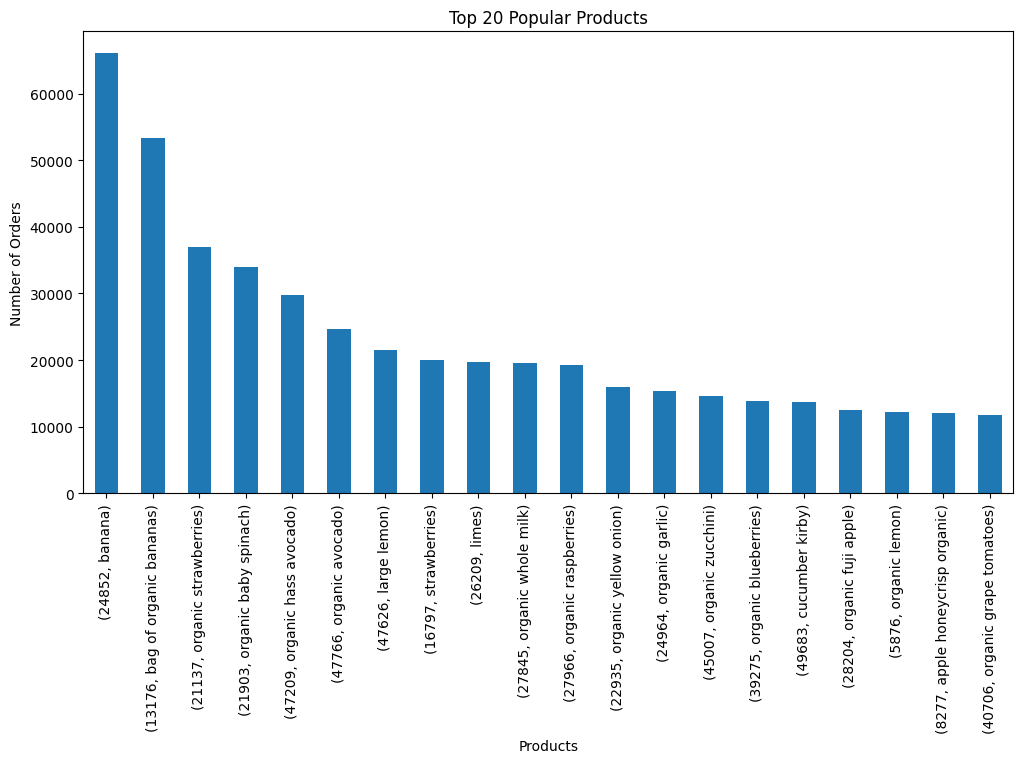

In [45]:
top_20.plot(title = 'Top 20 Popular Products', 
            ylabel = 'Number of Orders', 
            xlabel = 'Products',
            figsize = (12, 6),
            kind = 'bar')

plt.show()

The results of this step reveal the following:

## 
#### 
- The faster a product is likely to **spoil**, the more frequently it is reordered.
- Milk is the one item that stands out as not being in the produce department.

The top 20 items are all produce, except for the milk. Looks like people want delicious and nutritious!

### [C1] How many items do people typically buy in one order? What does the distribution look like?
To analyze how many items people typically buy in one order:

1. **Group the data** by `order_id` and count the number of products (`product_id`) in each order using `.count()`. This gives the number of items in each order.
2. **Aggregate the counts**: Use `.value_counts()` to determine how frequently different order sizes occur, and then sort the results with `.sort_index()` to organize by the number of items.
3. **Visualize the distribution**: Use a bar plot to show the frequency of orders for each size, with the x-axis representing the number of items and the y-axis representing the number of orders.

This will help understand the typical size of a grocery order and identify any trends in purchasing behavior.

In [46]:
group_ops = order_products.groupby('order_id')
number_per_order = group_ops['product_id'].count()

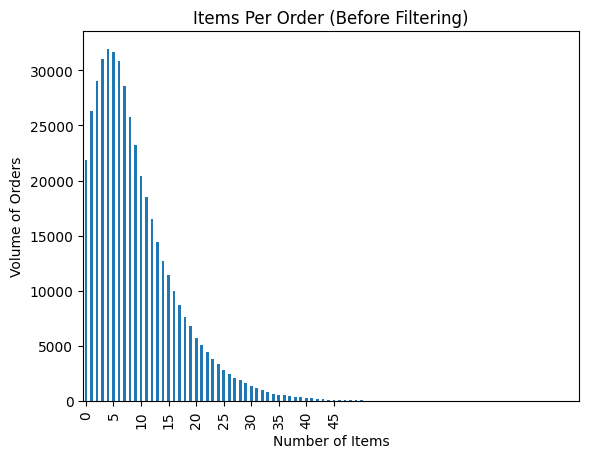

In [47]:
items_per_order = number_per_order.value_counts().sort_index()

#Added (Before Filtering) to make note that this is not the final visualization. The next will focus on the majority of the data.
items_per_order.plot(kind = 'bar',
                    title = 'Items Per Order (Before Filtering)',
                    xticks = range(0, 50, 5),
                    xlabel = 'Number of Items',
                    ylabel = 'Volume of Orders')

plt.show()


Most of the order numbers are in the tail of the distribution. To get a better look at the non-tail part, The analysis will choose a value in the tail as a cutoff and just plot order with fewer than that many items. An order size of 35 items is far enough into the tail for this.

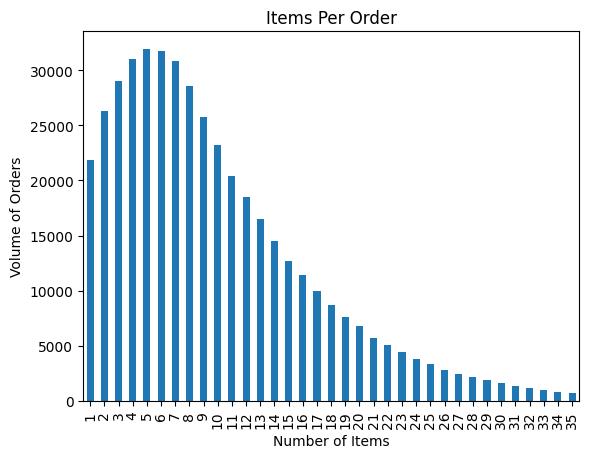

In [48]:
filtered_ipo = items_per_order[items_per_order.index <= 35] #Creating a filtered version of 'items_per_order'
filtered_ipo.plot(kind = 'bar',
                  title = 'Items Per Order',
                  xlabel = 'Number of Items',
                  ylabel = 'Volume of Orders')

plt.show()

The results of this step reveal the following:

## 
#### :
- Most orders include a total of 5 items, with 6 and 4 being the next most frequent number of items in a customer's cart before checkout.
- This data can be useful for limiting the scope of how many items are recommended at any given time, allowing them to quickly picture their order without much navigating.

The typical order contains 5 or 6 items, with most orders having between 1 and 20 items.

### [C2] What are the top 20 items that are reordered most frequently (display their names and product IDs)?

To find the top 20 most frequently reordered items:

1. **Filter the data**: Use `order_products['reordered'] == 1` to isolate only the products that have been reordered.
2. **Merge the datasets**: Combine the filtered `order_products` with the `products` dataset on `product_id` to get both the product names and IDs.
3. **Group the data**: Group by both `product_id` and `product_name` to calculate how many times each product was reordered, using `.size()`.
4. **Sort the results**: Use `.sort_values(ascending=False)` to rank the products by reorder frequency.
5. **Display the top 20**: Use `.head(20)` to focus on the most frequently reordered products.
6. **Visualize the data**: Create a bar chart to showcase the top reordered items and their frequencies.

This process highlights the products that customers consistently return to and reorder.

In [49]:
reordered_products = order_products[order_products['reordered'] == 1] #Filtering the DataFrame to only reordered products

In [50]:
#Combining 'reordered_products' and 'products' DataFrames on 'product_id'. This variable 'rp_combo' stands for reordered_products combination.
rp_combo = reordered_products.merge(products,
                                   left_on = 'product_id',
                                   right_on = 'product_id')

rp_combo = rp_combo.groupby(['product_id', 'product_name']).size() #Calculating how many times each product was reordered.

In [51]:
rp_combo = rp_combo.sort_values(ascending = False) #Sorting values in descending order.

rp_top_20 = rp_combo.head(20) #Filtering down to the top 20 most reordered items and storing them into a 'rp_top_20' variable.

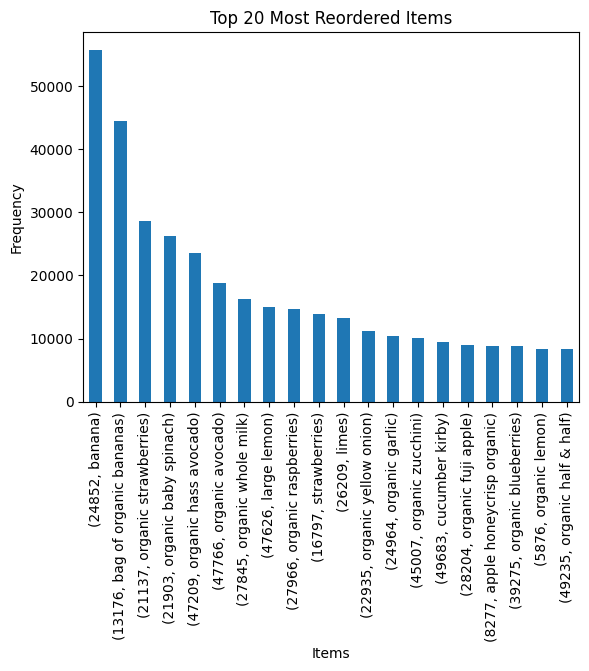

In [52]:
 

rp_top_20.plot(title = 'Top 20 Most Reordered Items',
              kind = 'bar',
              xlabel = 'Items',
              ylabel = 'Frequency')

plt.show()

The results of this step reveal the following:

## 
#### 
- The first three most reordered items really stand out: bananas, bag of organic bananas, and organic strawberies.
- After the first five most frequently reordered items, the frequency really starts to drop off.
- This information could be used for recommendation engines, especially when trying to recommend something to a new customer no data yet exists for.

It looks like produce and dairy comprise the most reordered products as well. It makes sense that perishables would be the most reordered items.

### [C3] For each product, what proportion of its orders are reorders?

To calculate the proportion of orders for each product that are reorders:

1. **Merge the datasets**: Combine `order_products` with the `products` dataset to access product names and IDs in the same DataFrame.
2. **Group the data**: Group by `product_id` and `product_name` to isolate each product's order history.
3. **Calculate the mean of `reordered`**: Use `.mean()` on the `reordered` column to compute the proportion of orders for each product that were reorders. The value represents the reorder rate.
4. **Sort the results**: Use `.sort_values(ascending=False)` to rank products by their reorder rates.
5. **Convert to a DataFrame**: Use `.reset_index()` to organize the grouped data into a readable DataFrame.
6. **Optional Sorting**: Sort the results by `product_id` or another column for better clarity.

This approach provides insights into how frequently each product is reordered, helping identify customer favorites or staples.


In [53]:
# I used the variable 'rp_per_item' to stand for 'Reorder Proportions Per Item', since this is what we are aiming to narrow in on.
rp_per_item = order_products.merge(products) #Merged 'order_products' and 'products' datasets.
rp_per_item = rp_per_item.groupby(['product_id', 'product_name']) #Isolated each product's order history
reorder_proportions = rp_per_item['reordered'].mean() #Here, I calculated teh reorder proportions per item.
sorted_rps = reorder_proportions.sort_values(ascending = False) #I used the new variable 'sorted_rps' to stand for 'Sorted Reorder Proportions'.
sorted_rps.reset_index() #Organized data into a readable DataFrame

,product_id,product_name,reordered
0,14721,bone strength take care,1.0
1,20949,vanilla sandwich cookies,1.0
2,6723,palmiers- petite,1.0
3,6732,naturally sparkling mineral water,1.0
4,45088,california dill pollen & garlic goat cheese & ...,1.0
...,...,...,...
45568,10485,caramel apple pop,0.0
45569,37690,calypso fresh 2x concentrated scentsations 166...,0.0
45570,10484,avocado and greens,0.0
45571,10474,nustevia white stevia powder,0.0


In [54]:
#To get a sense of what items fall within different segments, I've printed samples of 10 items for every increment of 10% in reorder proportions per item.
print((sorted_rps[sorted_rps == 1.0]).sample(10, random_state = 42))
print((sorted_rps[sorted_rps == 0.9]).sample(10, random_state = 42))
print((sorted_rps[sorted_rps == 0.8]).sample(10, random_state = 42))
print((sorted_rps[sorted_rps == 0.7]).sample(10, random_state = 42))
print((sorted_rps[sorted_rps == 0.6]).sample(10, random_state = 42))
print((sorted_rps[sorted_rps == 0.5]).sample(10, random_state = 42))
print((sorted_rps[sorted_rps == 0.4]).sample(10, random_state = 42))
print((sorted_rps[sorted_rps == 0.3]).sample(10, random_state = 42))
print((sorted_rps[sorted_rps == 0.2]).sample(10, random_state = 42))
print((sorted_rps[sorted_rps == 0.1]).sample(10, random_state = 42))
print((sorted_rps[sorted_rps == 0.0]).sample(10, random_state = 42))

product_id  product_name                                                              
15339       fuzzy navel cooler                                                            1.0
27491       gluten free whole grain southwest breaded chicken tenders                     1.0
41017       vegetarian falafel mix                                                        1.0
24196       special k fudge dipped pretzels                                               1.0
10813       jumbo ranch sunflower seeds                                                   1.0
32565       william fevre chablis champs royaux france                                    1.0
20270       seabreeze salad                                                               1.0
17404       sliced ham                                                                    1.0
1466        blended breakfast strawberry+banana+chia+ancient grains superfood smoothie    1.0
4804        multigrain cereal baby food                            

The results of this step reveal the following:

## 
#### :
- Reorder frequency appears to track how quickly a product is consumed or replaced. 
- The highest-reordered items are mostly perishable, everyday consumables, while the lowest-reordered items are typically durable, occasional-use, or one-time purchases.
- These reorder rates are useful for both recommendation systems, where it can guide repurchase suggestions, and forecasting, where it can help anticipate restocking demand.

The products that are most often placed into the cart first are produce, dairy, and beverages such as soda or water. I couldn't really say why that is without experience using Instacart because this could have more to do with app design than properties of the products. I do notice that there is considerable overlap between this result and the previous result for most popular and most reordered item types. It could simply be that the app prioritizes popular items as the first suggested purchases, so it happens to be more convenient for customers to place these items in their cart first.